In [17]:
import seaborn as sns
import json
from matplotlib import pyplot
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def extend(lst, desired_length, fill_value=None):
    return lst + [fill_value] * (desired_length - len(lst))

In [20]:
# Angle between two vectors in degrees.
def vang(a, b): 
    return np.arccos(a.dot(b)) / np.pi * 180

# Vector from two angles
def vec(x):
    return np.array([np.cos(x[0]) * np.sin(x[1]), np.sin(x[0]) * np.sin(x[1]), np.cos(x[1])])

# convert in-game angles to radian coordiantes
def gamea(a, b):
    return [b / 180 * np.pi, (90 - a) / 180 * np.pi]

# pixels distance between two vectors (a,b) and (c,d) defined by in-game angles.
def points(a, b, c, d):
    # 3/4 seems to be a change in game engine?
    return vang(vec(gamea(a, b)), vec(gamea(c, d))) / 0.022

def vector_length(x, y):
    return np.sqrt(x * x + y * y)

def diff(a, b):
#     return sum([abs(x[0] - x[1]) for x in zip(a, b)])
#     return pow(sum(d), 0.5)
    d = [pow(x[0] - x[1], 2) for x in zip(a, b)]
    return sum([max(x - 3, 0) for x in d])

def dist_score(x):
    return np.exp(-0.0004 * np.power(x, 2))

def rc_score(r1, r2):
    return 100 * np.mean([dist_score(vector_length(r1['x'][i] - r2['x'][i], r1['y'][i] - r2['y'][i])) for i in range(len(r1['x']))])

def median_delta_recoil(rc):
    mx = [0]
    my = [0]
    x = 0
    y = 0
    n = len(rc[0]['x'])
    for i in range(1, n):
        dx = []
        dy = []
        for r in rc:
            dx.append(r['x'][i] - r['x'][i-1])
            dy.append(r['y'][i] - r['y'][i-1])
        x += np.median(dx)
        y += np.median(dy)
        mx.append(np.round(x, 1))
        my.append(np.round(y, 1))
    return mx, my

def mean_recoil(rc):
    mx = [0]
    my = [0]
    x = 0
    y = 0
    n = len(rc[0]['x'])
    for i in range(1, n):
        dx = []
        dy = []
        for r in rc:
            dx.append(r['x'][i])
            dy.append(r['y'][i])
        x = np.mean(dx)
        y = np.mean(dy)
        mx.append(np.round(x, 1))
        my.append(np.round(y, 1))
    return mx, my

In [21]:
def rpm(name):
  with open('../client/specs.json') as f:
    specs = json.load(f)
  for x in specs:
    if x['name'] == name:
      return x['rpm']
  return 1

def to_game_distances(r):
  [ia, ib] = r['anchor_indexes']
  xa, ya = r['x'][ia], r['y'][ia]
  xb, yb = r['x'][ib], r['y'][ib]
  dg = r['anchor_in_game_distance']
  d = vector_length(xb - xa, yb - ya)
  r['x'] = [x * dg / d for x in r['x']]
  r['y'] = [y * dg / d for y in r['y']]
  return r

def get_recoils(w):
  with open('../client/raw_recoils.json') as f:
    raw = json.load(f)
  return [to_game_distances(x) for x in raw if x['weapon'] == w]

In [26]:
print(np.round(points(-3.16, 134.51, -13.95, 134.77), 2))
print(np.round(points(-16.09, -167.97, -5.71, -169.34), 2))
print(np.round(points(-18.22, -173.22, -6.04, -174.02), 2))
print(np.round(points(-17.60, -177.41, -5.94, -179.07), 2))
print(np.round(points(-17.18, -177.14, -6.10, 175.56), 2))
print(np.round(points(-18.44, 172.29, -6.20, 170.93), 2))

490.59
475.75
554.77
535.1
599.08
559.62


In [ ]:
# rc= [
#     {"version":2,"weapon":"havoc_tc","barrel":0,"stock":0,"comment":"havoc.png","x":[0,55,80,77,72,72,46,39,17,16,34,52,94,119,159,176,179,149,122,96,78,62,57,75,72,47,39,26,-10],"y":[0,-47,-134,-207,-259,-298,-321,-374,-406,-455,-483,-506,-514,-506,-498,-525,-556,-555,-580,-563,-580,-588,-624,-686,-727,-746,-799,-834,-855],"anchor_indexes":[],"anchor_in_game_distance":490.59}
# ]

# recoils 6
"x": [0, 17.6, 39.5, 31.4, 34.6, 27.8, 15.7, 11.1, -0.4, -4.2, 3.3, 16.3, 34.7, 51.4, 67.7, 73.6, 72.4, 58.9, 45.1, 26.9, 12.9, -1.5, -3.8, -0.6, -8.5, -19.7, -19.5, -31.1, -49.5],
"y": [0, -31.2, -83.7, -128.5, -164.1, -194.1, -212.7, -239.2, -261.2, -283.6, -302.4, -313.7, -321.9, -316.3, -314.9, -332.1, -346.0, -350.7, -363.8, -357.5, -362.5, -365.7, -388.7, -418.4, -443.3, -461.0, -492.3, -520.5, -533.0],
"time_points": [0, 89, 178, 267, 357, 446, 535, 625, 714, 803, 892, 982, 1071, 1160, 1250, 1339, 1428, 1517, 1607, 1696, 1785, 1875, 1964, 2053, 2142, 2232, 2321, 2410, 2500],
29 29 29 29


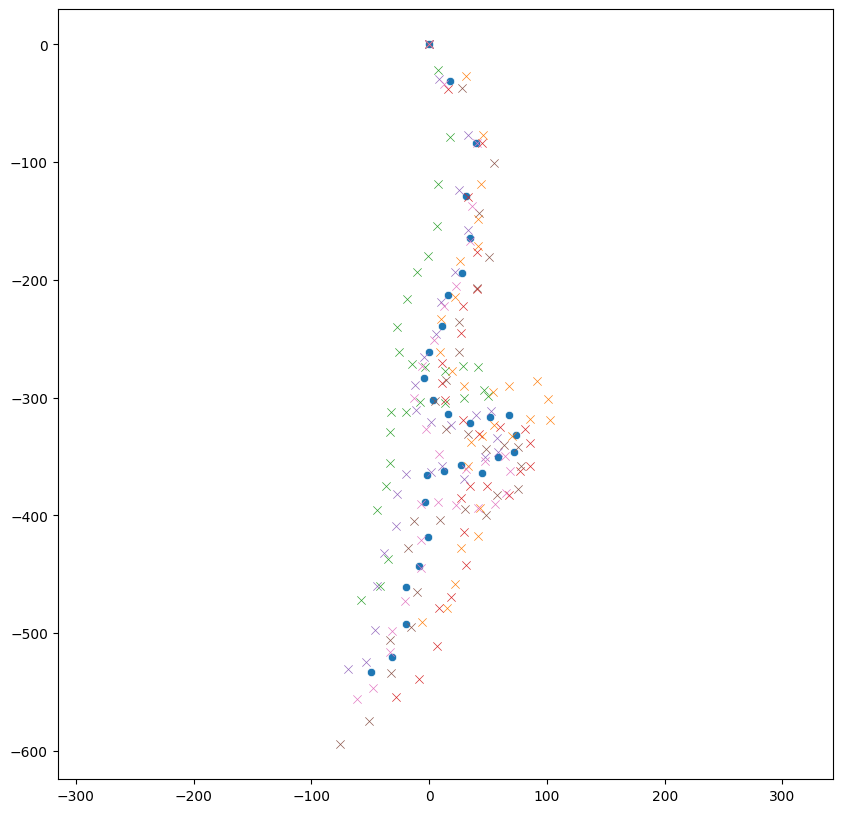

In [40]:
w = 'havoc_tc'
rc = get_recoils(w)
print('# recoils', len(rc))

_, ax = plt.subplots(figsize=(10,10))
plt.axis('equal')

n = len(rc[0]['x'])
wrpm = rpm(w)

x, y = mean_recoil(rc)
sns.scatterplot(ax=ax, x=x, y=y)

for r in rc:
    sns.scatterplot(ax=ax, x=r['x'], y=r['y'], marker='x')

t = [int(i * 60.0 * 1000 / wrpm) for i in range(n)]

s = json.dumps({
    'x': x,
    'y': y,
    'time_points': t,
    })
print(s.replace('], ','],\n')[1:-1] + ',')
print(n, len(x), len(y), len(t))

In [33]:
if len(rc) > 2:
  for i in range(len(rc)):
    sub = rc[:i] + rc[i+1:]
    tx, ty = mean_recoil(sub)
    print('w/o', i, ':', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in sub]))
else:
  print('not enough patterns')
# tx, ty = mean_delta_recoil(rc)
# print('mean_delta_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))
# tx, ty = median_delta_recoil(rc)
# print('median_delta_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))
# tx, ty = mean_delta2_recoil(rc)
# print('mean_delta2_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))

w/o 0 : 74.16071849680091
w/o 1 : 77.89788349307703
w/o 2 : 67.0438071661861
w/o 3 : 66.05799491341415
w/o 4 : 69.62106462426172
w/o 5 : 67.81030398955906


0 havoc_00.png 59.04544335565052
1 havoc_01.png 44.000437642508146
2 havoc_02.png 82.1447479253648
3 havoc_03.png 90.00199512126584
4 havoc_04.png 65.5552640567679
5 havoc_05.png 76.51107079562253
bad 1 havoc_01.png
[np.float64(6363569.109999996), np.float64(2531137.5000000047), np.float64(1298926.7900000003), np.float64(697594.2700000005), np.float64(234598.74999999977)]


(np.float64(0.10962311525834925),
 np.False_,
 [np.float64(59.04544335565052),
  np.float64(44.000437642508146),
  np.float64(82.1447479253648),
  np.float64(90.00199512126584),
  np.float64(65.5552640567679),
  np.float64(76.51107079562253)],
 'err',
 [np.float64(6363569.109999996),
  np.float64(2531137.5000000047),
  np.float64(1298926.7900000003),
  np.float64(697594.2700000005),
  np.float64(234598.74999999977)])

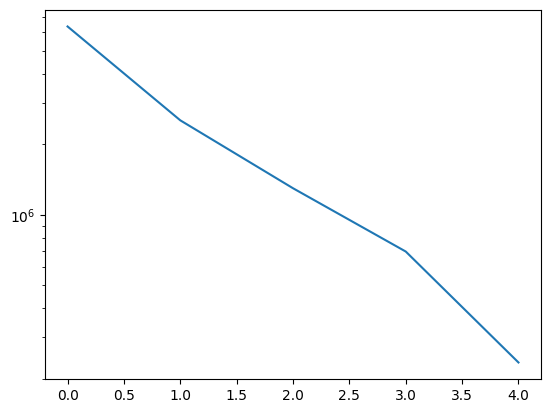

In [39]:
k = len(rc) - 1
err = [0] * k
maxerr = [0] * len(rc)
minerr = [100000000] * len(rc)
tx, ty = mean_recoil(rc)
for i in range(200):
    t = np.random.permutation(rc)
    for j in range(k):
        x, y = mean_recoil(t[:j+1])
        d = diff(x, tx) + diff(y, ty)
        err[j] += d
        minerr[j] = min(minerr[j], d)
        maxerr[j] = max(maxerr[j], d)

bd = 0
bi = 0
for i, r in enumerate(rc):
    print(i, r['comment'], rc_score(r, {'x': tx, 'y': ty}))
    d = diff(r['x'][:n], tx) + diff(r['y'][:n], ty)
    if d > bd:
        bd = d
        bi = i
print('bad', bi, rc[bi]['comment'])
print(err)
plt.yscale('log')
# plt.ylim(1, None)
sns.lineplot(x=range(k), y=err)
d = err[-2] / err[0]
d, d < 0.01, [rc_score(r, {'x': tx, 'y': ty}) for r in rc], 'err', err